# Experiment 6: Artificial Neural Networks

This notebook covers:
- Perceptron as a binary classifier (SGD)
- Perceptron as a function approximator
- MLP with Scikit-Learn (MLPClassifier)
- Choosing network structure
- Handling overfitting with regularization

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

# mlxtend for decision region plotting
# Install if needed: pip install mlxtend
try:
    from mlxtend.plotting import plot_decision_regions
except ImportError:
    print("mlxtend not found. Run: pip install mlxtend")

---
## Example 1 — Perceptron as Binary Classifier (AND gate)

A Perceptron with a **step activation function** trained using **SGD** to solve logical AND.

In [ ]:
class Perceptron:
    def __init__(self, input_size, learning_rate, epochs):
        self.weights = np.random.rand(input_size)
        self.bias = np.random.rand()
        self.learning_rate = learning_rate
        self.epochs = epochs

    def step_activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        net_input = np.dot(x, self.weights) + self.bias
        return self.step_activation(net_input)

    def trainSGD(self, X, y):
        mse_history = []
        for epoch in range(self.epochs):
            total_mse = 0.0
            indices = np.arange(len(X))
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            for i in range(len(X_shuffled)):
                prediction = self.predict(X_shuffled[i])
                error = y_shuffled[i] - prediction
                self.weights += self.learning_rate * error * X_shuffled[i]
                self.bias += self.learning_rate * error
                total_mse += error ** 2
            mean_mse = total_mse / len(X)
            mse_history.append(mean_mse)
            print(f"Epoch {epoch + 1}/{self.epochs}, MSE: {mean_mse:.4f}")
        return mse_history

    def test(self, X, y):
        correct = 0
        for i in range(len(X)):
            pred = self.predict(X[i])
            if pred == y[i]:
                correct += 1
            print(f"Input: {X[i]}, Prediction: {pred}, Actual: {y[i]}")
        accuracy = correct / len(X) * 100
        print(f"Accuracy: {accuracy:.2f}%")
        return accuracy

# AND gate data
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

np.random.seed(42)
perceptron_and = Perceptron(input_size=2, learning_rate=0.01, epochs=10)
perceptron_and.trainSGD(X_and, y_and)
print("\n--- Test Results ---")
perceptron_and.test(X_and, y_and)

Epoch 1/10, MSE: 0.7500
Epoch 2/10, MSE: 0.7500
Epoch 3/10, MSE: 0.7500
Epoch 4/10, MSE: 0.7500
Epoch 5/10, MSE: 0.7500
Epoch 6/10, MSE: 0.7500
Epoch 7/10, MSE: 0.7500
Epoch 8/10, MSE: 0.7500
Epoch 9/10, MSE: 0.7500
Epoch 10/10, MSE: 0.7500

--- Test Results ---
Input: [0 0], Prediction: 1, Actual: 0
Input: [0 1], Prediction: 1, Actual: 0
Input: [1 0], Prediction: 1, Actual: 0
Input: [1 1], Prediction: 1, Actual: 1
Accuracy: 25.00%


25.0

---
## Task 6.1 — Effect of More Epochs on AND gate

Run with epochs = 10, 20, 100, 200 and compare accuracy.

Epoch 1/10, MSE: 0.7500
Epoch 2/10, MSE: 0.7500
Epoch 3/10, MSE: 0.7500
Epoch 4/10, MSE: 0.7500
Epoch 5/10, MSE: 0.7500
Epoch 6/10, MSE: 0.7500
Epoch 7/10, MSE: 0.7500
Epoch 8/10, MSE: 0.7500
Epoch 9/10, MSE: 0.7500
Epoch 10/10, MSE: 0.7500
Epochs=10 → Accuracy: 25.00%
Epoch 1/20, MSE: 0.7500
Epoch 2/20, MSE: 0.7500
Epoch 3/20, MSE: 0.7500
Epoch 4/20, MSE: 0.7500
Epoch 5/20, MSE: 0.7500
Epoch 6/20, MSE: 0.7500
Epoch 7/20, MSE: 0.7500
Epoch 8/20, MSE: 0.7500
Epoch 9/20, MSE: 0.7500
Epoch 10/20, MSE: 0.7500
Epoch 11/20, MSE: 0.7500
Epoch 12/20, MSE: 0.7500
Epoch 13/20, MSE: 0.7500
Epoch 14/20, MSE: 0.7500
Epoch 15/20, MSE: 0.7500
Epoch 16/20, MSE: 0.7500
Epoch 17/20, MSE: 0.7500
Epoch 18/20, MSE: 0.7500
Epoch 19/20, MSE: 0.7500
Epoch 20/20, MSE: 0.7500
Epochs=20 → Accuracy: 25.00%
Epoch 1/100, MSE: 0.7500
Epoch 2/100, MSE: 0.7500
Epoch 3/100, MSE: 0.7500
Epoch 4/100, MSE: 0.7500
Epoch 5/100, MSE: 0.7500
Epoch 6/100, MSE: 0.7500
Epoch 7/100, MSE: 0.7500
Epoch 8/100, MSE: 0.7500
Epoch 9/10

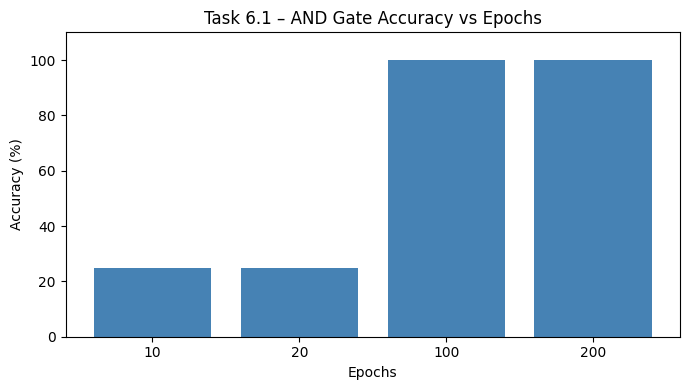

In [ ]:
epochs_list = [10, 20, 100, 200]
accuracies_61 = []

for ep in epochs_list:
    np.random.seed(42)
    p = Perceptron(input_size=2, learning_rate=0.01, epochs=ep)
    p.trainSGD(X_and, y_and)
    correct = sum(p.predict(X_and[i]) == y_and[i] for i in range(len(X_and)))
    acc = correct / len(X_and) * 100
    accuracies_61.append(acc)
    print(f"Epochs={ep} → Accuracy: {acc:.2f}%\n{'='*40}")

plt.figure(figsize=(7, 4))
plt.bar([str(e) for e in epochs_list], accuracies_61, color='steelblue')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Task 6.1 – AND Gate Accuracy vs Epochs')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

# --- Your observation below ---
# The AND gate is linearly separable, so the perceptron converges quickly.
# Running more epochs is not necessary once it already achieves 100% accuracy.

---
## Task 6.2 — Effect of Higher Learning Rate

Epoch 1/10, MSE: 0.7500
Epoch 2/10, MSE: 0.7500
Epoch 3/10, MSE: 0.7500
Epoch 4/10, MSE: 0.7500
Epoch 5/10, MSE: 0.7500
Epoch 6/10, MSE: 0.5000
Epoch 7/10, MSE: 0.2500
Epoch 8/10, MSE: 0.2500
Epoch 9/10, MSE: 0.2500
Epoch 10/10, MSE: 0.2500
LR=0.05 → Accuracy: 75.00%
Epoch 1/10, MSE: 0.7500
Epoch 2/10, MSE: 0.7500
Epoch 3/10, MSE: 0.7500
Epoch 4/10, MSE: 0.2500
Epoch 5/10, MSE: 0.2500
Epoch 6/10, MSE: 0.5000
Epoch 7/10, MSE: 0.2500
Epoch 8/10, MSE: 0.0000
Epoch 9/10, MSE: 0.0000
Epoch 10/10, MSE: 0.0000
LR=0.1 → Accuracy: 100.00%
Epoch 1/10, MSE: 0.7500
Epoch 2/10, MSE: 0.2500
Epoch 3/10, MSE: 0.5000
Epoch 4/10, MSE: 0.2500
Epoch 5/10, MSE: 0.5000
Epoch 6/10, MSE: 0.2500
Epoch 7/10, MSE: 0.2500
Epoch 8/10, MSE: 0.0000
Epoch 9/10, MSE: 0.0000
Epoch 10/10, MSE: 0.0000
LR=0.3 → Accuracy: 100.00%


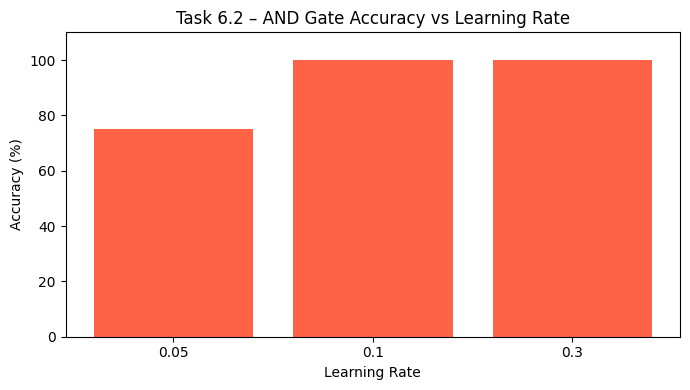

In [ ]:
lr_list = [0.05, 0.1, 0.3]
accuracies_62 = []

for lr in lr_list:
    np.random.seed(42)
    p = Perceptron(input_size=2, learning_rate=lr, epochs=10)
    p.trainSGD(X_and, y_and)
    correct = sum(p.predict(X_and[i]) == y_and[i] for i in range(len(X_and)))
    acc = correct / len(X_and) * 100
    accuracies_62.append(acc)
    print(f"LR={lr} → Accuracy: {acc:.2f}%\n{'='*40}")

plt.figure(figsize=(7, 4))
plt.bar([str(lr) for lr in lr_list], accuracies_62, color='tomato')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy (%)')
plt.title('Task 6.2 – AND Gate Accuracy vs Learning Rate')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

# --- Observation ---
# Higher LR can speed up convergence on simple problems.
# Too high LR may cause oscillation and instability.

---
## Example 2 — Perceptron as Linear Function Approximator

Approximate f(x) = 3x + 2 using a Perceptron with a **linear activation function** and **SGD**.

In [ ]:
class PerceptronLinear:
    def __init__(self, input_size, learning_rate, epochs):
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()
        self.learning_rate = learning_rate
        self.epochs = epochs

    def linear(self, x):
        return x

    def linear_derivative(self, x):
        return 1

    def predict(self, x):
        net_input = np.dot(x, self.weights) + self.bias
        return self.linear(net_input)

    def trainSGD(self, X, y):
        mse_history = []
        for epoch in range(self.epochs):
            total_mse = 0.0
            indices = np.arange(len(X))
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            Y_shuffled = y[indices]
            for i in range(len(X)):
                prediction = self.predict(X_shuffled[i])
                error = Y_shuffled[i] - prediction
                delta = error * self.linear_derivative(prediction)
                self.weights += self.learning_rate * delta * X_shuffled[i]
                self.bias += self.learning_rate * delta
                total_mse += error ** 2
            mean_mse = total_mse / len(X)
            mse_history.append(mean_mse)
            print(f"Epoch {epoch + 1}/{self.epochs}, MSE: {mean_mse:.4f}")
        return mse_history

# Generate synthetic data for f(x) = 3x + 2
np.random.seed(42)
num_samples = 100
x_data = np.random.uniform(low=0, high=10, size=num_samples)
z_data = 3 * x_data + 2

data_df = pd.DataFrame({'x': x_data, 'z': z_data})
F = data_df.iloc[:, :-1].values
O = data_df.iloc[:, -1].values

perceptron_lin = PerceptronLinear(input_size=1, learning_rate=0.001, epochs=10)
mse_history_63 = perceptron_lin.trainSGD(F, O)

Epoch 1/10, MSE: 54.4299
Epoch 2/10, MSE: 0.9345
Epoch 3/10, MSE: 0.8204
Epoch 4/10, MSE: 0.7764
Epoch 5/10, MSE: 0.7368
Epoch 6/10, MSE: 0.6914
Epoch 7/10, MSE: 0.6586
Epoch 8/10, MSE: 0.6233
Epoch 9/10, MSE: 0.5877
Epoch 10/10, MSE: 0.5563


---
## Task 6.3 — Observe prediction vs actual (10 epochs)

In [ ]:
print(f"{'Input':>10} | {'Actual':>10} | {'Predicted':>12} | {'Error':>10}")
print("-" * 50)
for xi in x_data[:10]:  # show first 10
    pred_array = perceptron_lin.predict(xi)
    pred = pred_array.item() # Extract scalar from the numpy array
    actual = 3 * xi + 2
    print(f"{xi:>10.4f} | {actual:>10.4f} | {pred:>12.4f} | {abs(actual - pred):>10.4f}")

     Input |     Actual |    Predicted |      Error
--------------------------------------------------
    3.7454 |    13.2362 |      12.6662 |     0.5700
    9.5071 |    30.5214 |      31.1863 |     0.6649
    7.3199 |    23.9598 |      24.1559 |     0.1961
    5.9866 |    19.9598 |      19.8701 |     0.0897
    1.5602 |     6.6806 |       5.6421 |     1.0384
    1.5599 |     6.6798 |       5.6414 |     1.0385
    0.5808 |     3.7425 |       2.4942 |     1.2483
    8.6618 |    27.9853 |      28.4690 |     0.4837
    6.0112 |    20.0335 |      19.9490 |     0.0844
    7.0807 |    23.2422 |      23.3870 |     0.1448


---
## Task 6.4 — Run with 100 epochs and compare MSE

In [ ]:
np.random.seed(42)
perceptron_lin_100 = PerceptronLinear(input_size=1, learning_rate=0.001, epochs=100)
mse_history_64 = perceptron_lin_100.trainSGD(F, O)

print(f"\nFinal MSE (10 epochs):  {mse_history_63[-1]:.4f}")
print(f"Final MSE (100 epochs): {mse_history_64[-1]:.4f}")

# --- Justification ---
# With more epochs, SGD has more iterations to update weights,
# leading to a lower MSE and predictions closer to the true function.

Epoch 1/100, MSE: 40.9211
Epoch 2/100, MSE: 0.8417
Epoch 3/100, MSE: 0.7396
Epoch 4/100, MSE: 0.7000
Epoch 5/100, MSE: 0.6610
Epoch 6/100, MSE: 0.6185
Epoch 7/100, MSE: 0.5926
Epoch 8/100, MSE: 0.5594
Epoch 9/100, MSE: 0.5294
Epoch 10/100, MSE: 0.5002
Epoch 11/100, MSE: 0.4724
Epoch 12/100, MSE: 0.4480
Epoch 13/100, MSE: 0.4230
Epoch 14/100, MSE: 0.4001
Epoch 15/100, MSE: 0.3731
Epoch 16/100, MSE: 0.3605
Epoch 17/100, MSE: 0.3389
Epoch 18/100, MSE: 0.3213
Epoch 19/100, MSE: 0.3032
Epoch 20/100, MSE: 0.2866
Epoch 21/100, MSE: 0.2706
Epoch 22/100, MSE: 0.2550
Epoch 23/100, MSE: 0.2434
Epoch 24/100, MSE: 0.2294
Epoch 25/100, MSE: 0.2176
Epoch 26/100, MSE: 0.2058
Epoch 27/100, MSE: 0.1947
Epoch 28/100, MSE: 0.1822
Epoch 29/100, MSE: 0.1746
Epoch 30/100, MSE: 0.1642
Epoch 31/100, MSE: 0.1561
Epoch 32/100, MSE: 0.1474
Epoch 33/100, MSE: 0.1393
Epoch 34/100, MSE: 0.1312
Epoch 35/100, MSE: 0.1249
Epoch 36/100, MSE: 0.1180
Epoch 37/100, MSE: 0.1114
Epoch 38/100, MSE: 0.1053
Epoch 39/100, MSE: 0

---
## Task 6.5 — Plot MSE vs Epoch and Actual vs Approximated Function

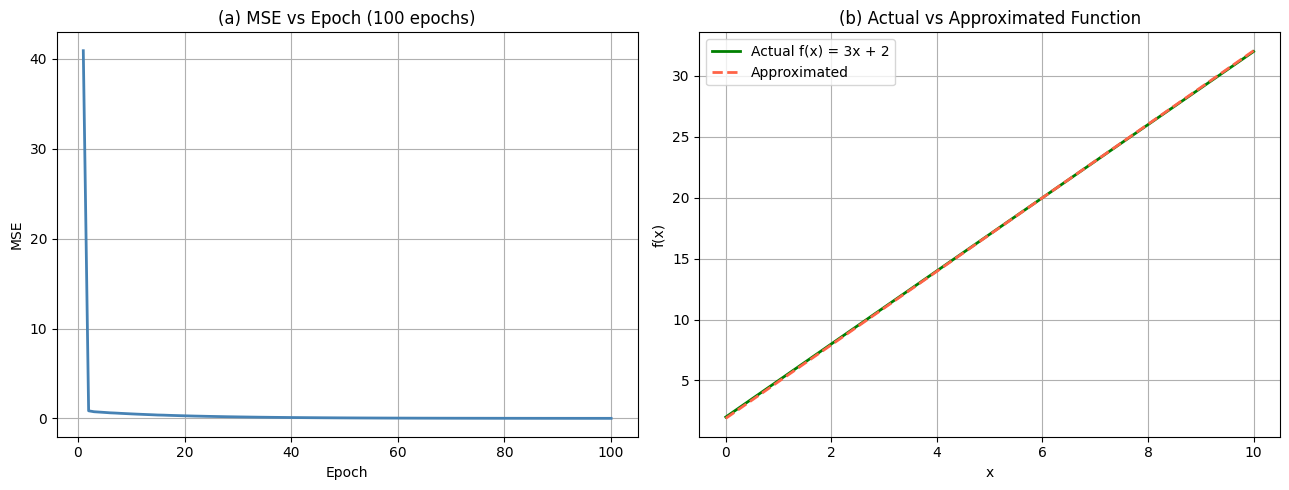

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) MSE vs Epoch
axes[0].plot(range(1, 101), mse_history_64, color='steelblue', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('(a) MSE vs Epoch (100 epochs)')
axes[0].grid(True)

# (b) Actual vs Approximated function
x_range = np.linspace(0, 10, 200)
y_actual = 3 * x_range + 2
y_approx = np.array([perceptron_lin_100.predict(xi) for xi in x_range])

axes[1].plot(x_range, y_actual, label='Actual f(x) = 3x + 2', color='green', linewidth=2)
axes[1].plot(x_range, y_approx, label='Approximated', color='tomato', linewidth=2, linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('(b) Actual vs Approximated Function')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Task 6.6 — Approximate f(x, y) = 2x + 3y

Epoch 1/100, MSE: 75.4408
Epoch 2/100, MSE: 0.1795
Epoch 3/100, MSE: 0.0986
Epoch 4/100, MSE: 0.0824
Epoch 5/100, MSE: 0.0788
Epoch 6/100, MSE: 0.0753
Epoch 7/100, MSE: 0.0731
Epoch 8/100, MSE: 0.0710
Epoch 9/100, MSE: 0.0695
Epoch 10/100, MSE: 0.0658
Epoch 11/100, MSE: 0.0657
Epoch 12/100, MSE: 0.0636
Epoch 13/100, MSE: 0.0599
Epoch 14/100, MSE: 0.0594
Epoch 15/100, MSE: 0.0577
Epoch 16/100, MSE: 0.0553
Epoch 17/100, MSE: 0.0543
Epoch 18/100, MSE: 0.0529
Epoch 19/100, MSE: 0.0507
Epoch 20/100, MSE: 0.0490
Epoch 21/100, MSE: 0.0485
Epoch 22/100, MSE: 0.0470
Epoch 23/100, MSE: 0.0458
Epoch 24/100, MSE: 0.0441
Epoch 25/100, MSE: 0.0425
Epoch 26/100, MSE: 0.0416
Epoch 27/100, MSE: 0.0406
Epoch 28/100, MSE: 0.0385
Epoch 29/100, MSE: 0.0379
Epoch 30/100, MSE: 0.0369
Epoch 31/100, MSE: 0.0353
Epoch 32/100, MSE: 0.0348
Epoch 33/100, MSE: 0.0337
Epoch 34/100, MSE: 0.0326
Epoch 35/100, MSE: 0.0316
Epoch 36/100, MSE: 0.0309
Epoch 37/100, MSE: 0.0299
Epoch 38/100, MSE: 0.0287
Epoch 39/100, MSE: 0

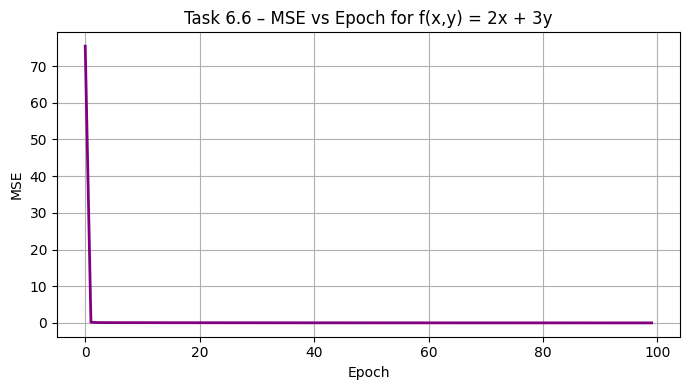

In [ ]:
np.random.seed(42)
num_samples = 100
x1 = np.random.uniform(0, 10, num_samples)
x2 = np.random.uniform(0, 10, num_samples)
z_2d = 2 * x1 + 3 * x2

F_2d = np.column_stack([x1, x2])
O_2d = z_2d

perceptron_2d = PerceptronLinear(input_size=2, learning_rate=0.001, epochs=100)
mse_history_66 = perceptron_2d.trainSGD(F_2d, O_2d)

print("\n--- Sample Predictions ---")
print(f"{'x1':>6} {'x2':>6} | {'Actual':>10} | {'Predicted':>12} | {'Error':>8}")
print("-" * 50)
for i in range(10):
    pred = perceptron_2d.predict(F_2d[i])
    actual = O_2d[i]
    print(f"{x1[i]:>6.3f} {x2[i]:>6.3f} | {actual:>10.4f} | {pred:>12.4f} | {abs(actual-pred):>8.4f}")

plt.figure(figsize=(7, 4))
plt.plot(mse_history_66, color='purple', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Task 6.6 – MSE vs Epoch for f(x,y) = 2x + 3y')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Task 6.7 — Perceptron on XOR (1000 epochs)

In [ ]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

np.random.seed(42)
p_xor_1000 = Perceptron(input_size=2, learning_rate=0.01, epochs=1000)
p_xor_1000.trainSGD(X_xor, y_xor)

print("\n--- Test Results (XOR, 1000 epochs) ---")
acc_xor_1000 = p_xor_1000.test(X_xor, y_xor)

# --- Observation ---
# XOR is not linearly separable → perceptron cannot classify it correctly.
# Accuracy will be at most 75%, even with many epochs.

Epoch 1/1000, MSE: 0.5000
Epoch 2/1000, MSE: 0.5000
Epoch 3/1000, MSE: 0.5000
Epoch 4/1000, MSE: 0.5000
Epoch 5/1000, MSE: 0.5000
Epoch 6/1000, MSE: 0.5000
Epoch 7/1000, MSE: 0.5000
Epoch 8/1000, MSE: 0.5000
Epoch 9/1000, MSE: 0.5000
Epoch 10/1000, MSE: 0.5000
Epoch 11/1000, MSE: 0.5000
Epoch 12/1000, MSE: 0.5000
Epoch 13/1000, MSE: 0.5000
Epoch 14/1000, MSE: 0.5000
Epoch 15/1000, MSE: 0.5000
Epoch 16/1000, MSE: 0.5000
Epoch 17/1000, MSE: 0.5000
Epoch 18/1000, MSE: 0.5000
Epoch 19/1000, MSE: 0.5000
Epoch 20/1000, MSE: 0.5000
Epoch 21/1000, MSE: 0.5000
Epoch 22/1000, MSE: 0.5000
Epoch 23/1000, MSE: 0.5000
Epoch 24/1000, MSE: 0.5000
Epoch 25/1000, MSE: 0.5000
Epoch 26/1000, MSE: 0.5000
Epoch 27/1000, MSE: 0.5000
Epoch 28/1000, MSE: 0.5000
Epoch 29/1000, MSE: 0.5000
Epoch 30/1000, MSE: 0.5000
Epoch 31/1000, MSE: 0.5000
Epoch 32/1000, MSE: 0.5000
Epoch 33/1000, MSE: 0.5000
Epoch 34/1000, MSE: 0.5000
Epoch 35/1000, MSE: 0.5000
Epoch 36/1000, MSE: 0.5000
Epoch 37/1000, MSE: 0.5000
Epoch 38/1

---
## Task 6.8 — Perceptron on XOR (10000 epochs)

In [ ]:
np.random.seed(42)
p_xor_10000 = Perceptron(input_size=2, learning_rate=0.01, epochs=10000)
p_xor_10000.trainSGD(X_xor, y_xor)

print("\n--- Test Results (XOR, 10000 epochs) ---")
acc_xor_10000 = p_xor_10000.test(X_xor, y_xor)

print(f"\nAccuracy (1000 epochs):  {acc_xor_1000:.2f}%")
print(f"Accuracy (10000 epochs): {acc_xor_10000:.2f}%")

# --- Justification ---
# More epochs do NOT help. The XOR decision boundary is inherently nonlinear.
# A single-layer perceptron can only form a linear boundary, which is insufficient for XOR.
# An MLP with at least one hidden layer is required to solve XOR.

Streaming output truncated to the last 5000 lines.
Epoch 5011/10000, MSE: 1.0000
Epoch 5012/10000, MSE: 0.5000
Epoch 5013/10000, MSE: 1.0000
Epoch 5014/10000, MSE: 0.7500
Epoch 5015/10000, MSE: 0.7500
Epoch 5016/10000, MSE: 1.0000
Epoch 5017/10000, MSE: 0.5000
Epoch 5018/10000, MSE: 0.7500
Epoch 5019/10000, MSE: 0.5000
Epoch 5020/10000, MSE: 0.7500
Epoch 5021/10000, MSE: 1.0000
Epoch 5022/10000, MSE: 0.5000
Epoch 5023/10000, MSE: 0.7500
Epoch 5024/10000, MSE: 0.7500
Epoch 5025/10000, MSE: 0.7500
Epoch 5026/10000, MSE: 0.7500
Epoch 5027/10000, MSE: 1.0000
Epoch 5028/10000, MSE: 0.7500
Epoch 5029/10000, MSE: 1.0000
Epoch 5030/10000, MSE: 1.0000
Epoch 5031/10000, MSE: 0.7500
Epoch 5032/10000, MSE: 0.5000
Epoch 5033/10000, MSE: 1.0000
Epoch 5034/10000, MSE: 0.5000
Epoch 5035/10000, MSE: 1.0000
Epoch 5036/10000, MSE: 1.0000
Epoch 5037/10000, MSE: 0.5000
Epoch 5038/10000, MSE: 0.7500
Epoch 5039/10000, MSE: 0.2500
Epoch 5040/10000, MSE: 0.7500
Epoch 5041/10000, MSE: 0.5000
Epoch 5042/10000, M

---
## Example 3 — MLPClassifier on Iris Dataset

Example 3 Test Accuracy: 0.4000


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


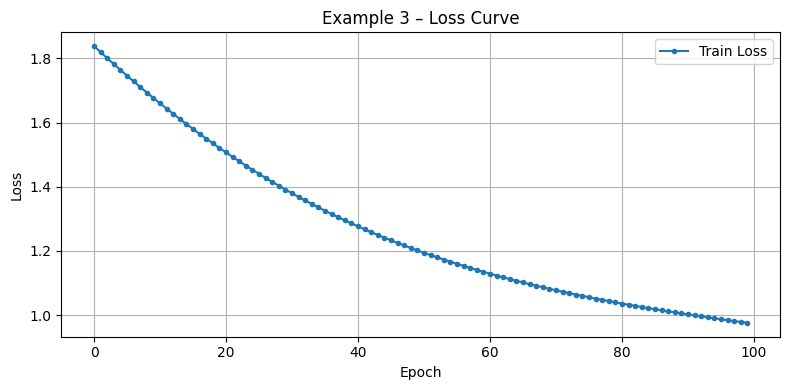

In [ ]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42)

mlp_ex3 = MLPClassifier(hidden_layer_sizes=(10,), max_iter=100, random_state=42)
mlp_ex3.fit(X_train_iris, y_train_iris)

y_pred_ex3 = mlp_ex3.predict(X_test_iris)
acc_ex3 = accuracy_score(y_test_iris, y_pred_ex3)
print(f"Example 3 Test Accuracy: {acc_ex3:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(mlp_ex3.loss_curve_, marker='o', markersize=3, label='Train Loss')
plt.title('Example 3 – Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Task 6.9 — MLPClassifier with Different Configurations

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Config 1: (10,) ReLU default
  Accuracy: 0.9667  |  Final Loss: 0.1343

Config 2: (50,) ReLU lr=0.01
  Accuracy: 1.0000  |  Final Loss: 0.0551

Config 3: (35,15) Tanh lr=0.01
  Accuracy: 1.0000  |  Final Loss: 0.0495



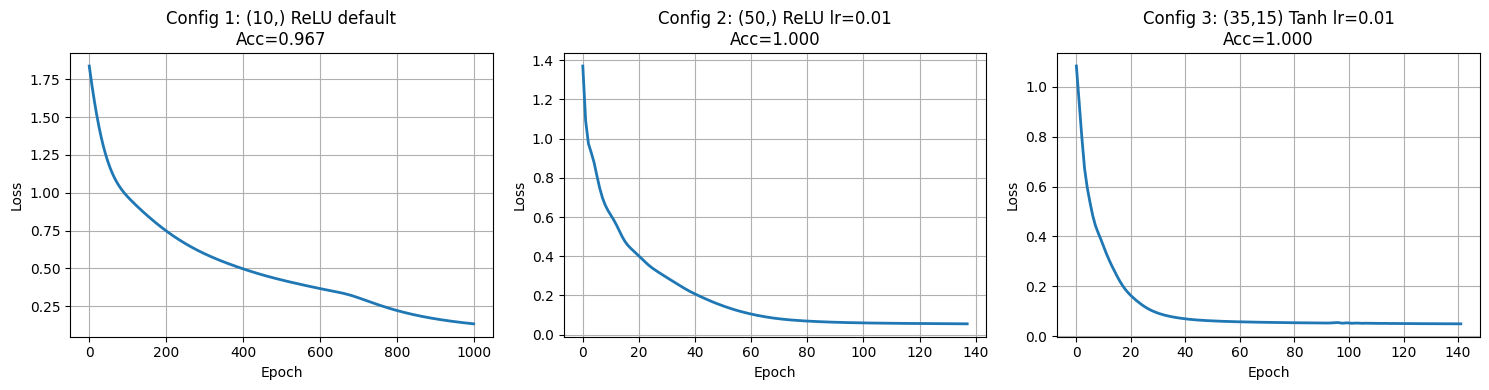

In [ ]:
configs = [
    dict(hidden_layer_sizes=(10,),    max_iter=1000, random_state=42,
         label='Config 1: (10,) ReLU default'),
    dict(hidden_layer_sizes=(50,),    max_iter=1000, random_state=42,
         activation='relu', learning_rate_init=0.01,
         label='Config 2: (50,) ReLU lr=0.01'),
    dict(hidden_layer_sizes=(35, 15), max_iter=1000, random_state=42,
         activation='tanh', learning_rate_init=0.01,
         label='Config 3: (35,15) Tanh lr=0.01'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, cfg in enumerate(configs):
    label = cfg.pop('label')
    mlp = MLPClassifier(**cfg)
    mlp.fit(X_train_iris, y_train_iris)
    y_pred = mlp.predict(X_test_iris)
    acc = accuracy_score(y_test_iris, y_pred)
    print(f"{label}")
    print(f"  Accuracy: {acc:.4f}  |  Final Loss: {mlp.loss_curve_[-1]:.4f}\n")

    axes[i].plot(mlp.loss_curve_, linewidth=2)
    axes[i].set_title(f'{label}\nAcc={acc:.3f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

---
## Example 4 — Decision Boundaries with Information Gain Feature Selection

MLP1 (50,)    Accuracy: 1.0000
MLP2 (35,15)  Accuracy: 1.0000


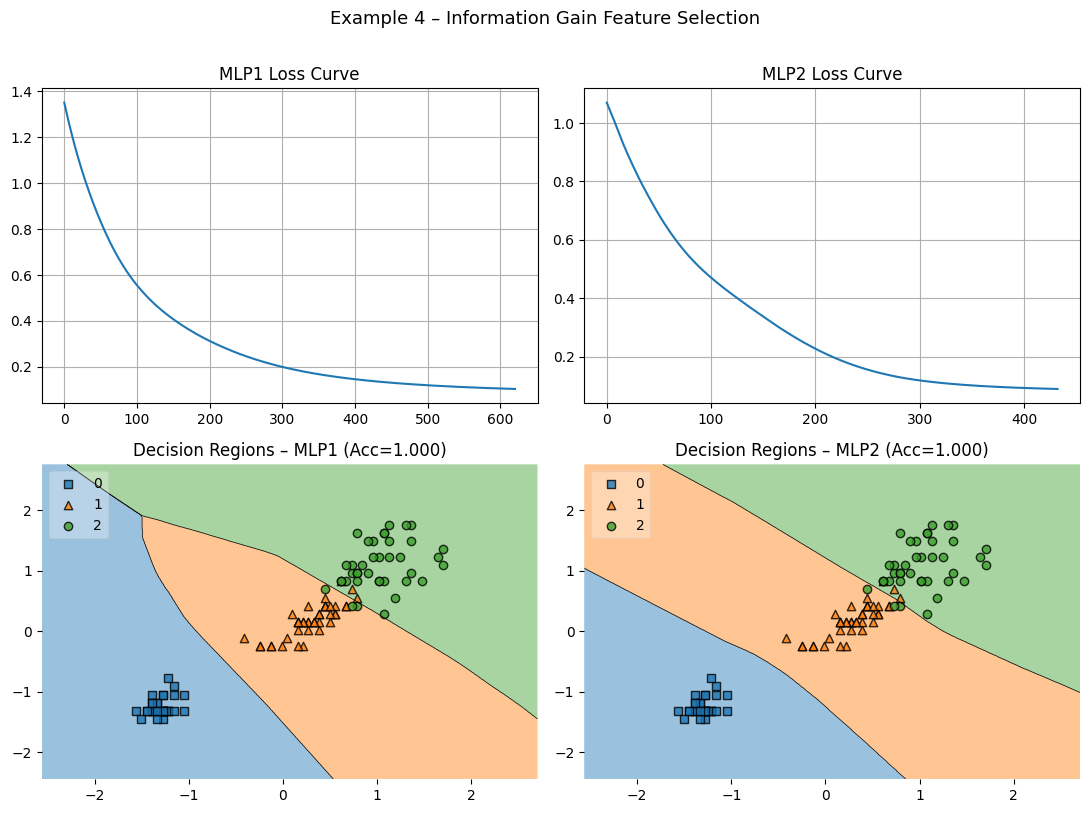

In [ ]:
# Select top 2 features by information gain
k_best = SelectKBest(score_func=mutual_info_classif, k=2)
X_ig = k_best.fit_transform(X_iris, y_iris)

X_train_ig, X_test_ig, y_train_ig, y_test_ig = train_test_split(
    X_ig, y_iris, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_ig = scaler.fit_transform(X_train_ig)
X_test_ig  = scaler.transform(X_test_ig)

mlp4_1 = MLPClassifier(hidden_layer_sizes=(50,),    max_iter=1000, random_state=42)
mlp4_2 = MLPClassifier(hidden_layer_sizes=(35, 15), max_iter=1000, random_state=42)
mlp4_1.fit(X_train_ig, y_train_ig)
mlp4_2.fit(X_train_ig, y_train_ig)

acc1 = accuracy_score(y_test_ig, mlp4_1.predict(X_test_ig))
acc2 = accuracy_score(y_test_ig, mlp4_2.predict(X_test_ig))
print(f"MLP1 (50,)    Accuracy: {acc1:.4f}")
print(f"MLP2 (35,15)  Accuracy: {acc2:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(mlp4_1.loss_curve_); axes[0, 0].set_title('MLP1 Loss Curve'); axes[0, 0].grid(True)
axes[0, 1].plot(mlp4_2.loss_curve_); axes[0, 1].set_title('MLP2 Loss Curve'); axes[0, 1].grid(True)
plot_decision_regions(X_train_ig, y_train_ig, clf=mlp4_1, legend=2, ax=axes[1, 0])
axes[1, 0].set_title(f'Decision Regions – MLP1 (Acc={acc1:.3f})')
plot_decision_regions(X_train_ig, y_train_ig, clf=mlp4_2, legend=2, ax=axes[1, 1])
axes[1, 1].set_title(f'Decision Regions – MLP2 (Acc={acc2:.3f})')
plt.suptitle('Example 4 – Information Gain Feature Selection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Task 6.10 answer ---
# Compare the decision boundaries visually.
# The model with cleaner, smoother regions that still achieves high accuracy is better.
# Overly complex boundaries may indicate overfitting.

---
## Task 6.11 — Decision Boundaries with PCA Feature Selection

PCA MLP1 (50,)    Accuracy: 1.0000
PCA MLP2 (35,15)  Accuracy: 1.0000


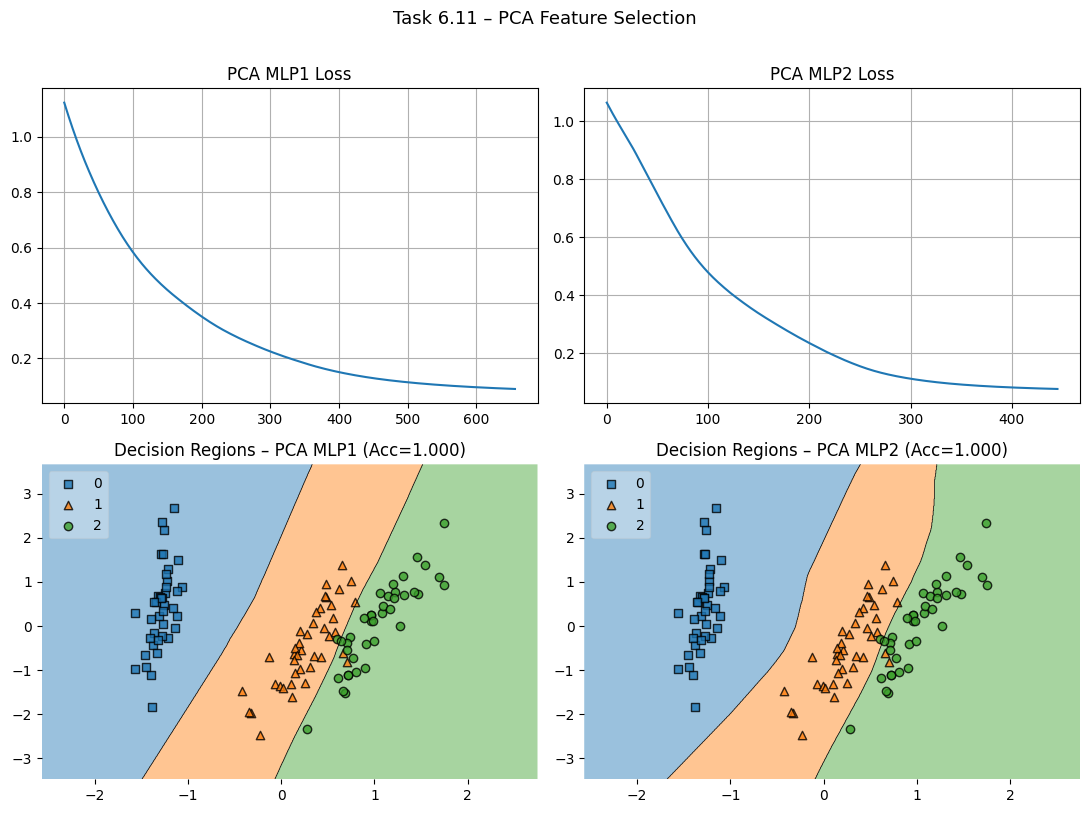

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_iris, test_size=0.2, random_state=42)

scaler_pca = StandardScaler()
X_train_pca = scaler_pca.fit_transform(X_train_pca)
X_test_pca  = scaler_pca.transform(X_test_pca)

mlp_pca1 = MLPClassifier(hidden_layer_sizes=(50,),    max_iter=1000, random_state=42)
mlp_pca2 = MLPClassifier(hidden_layer_sizes=(35, 15), max_iter=1000, random_state=42)
mlp_pca1.fit(X_train_pca, y_train_pca)
mlp_pca2.fit(X_train_pca, y_train_pca)

acc_pca1 = accuracy_score(y_test_pca, mlp_pca1.predict(X_test_pca))
acc_pca2 = accuracy_score(y_test_pca, mlp_pca2.predict(X_test_pca))
print(f"PCA MLP1 (50,)    Accuracy: {acc_pca1:.4f}")
print(f"PCA MLP2 (35,15)  Accuracy: {acc_pca2:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(mlp_pca1.loss_curve_); axes[0, 0].set_title('PCA MLP1 Loss'); axes[0, 0].grid(True)
axes[0, 1].plot(mlp_pca2.loss_curve_); axes[0, 1].set_title('PCA MLP2 Loss'); axes[0, 1].grid(True)
plot_decision_regions(X_train_pca, y_train_pca, clf=mlp_pca1, legend=2, ax=axes[1, 0])
axes[1, 0].set_title(f'Decision Regions – PCA MLP1 (Acc={acc_pca1:.3f})')
plot_decision_regions(X_train_pca, y_train_pca, clf=mlp_pca2, legend=2, ax=axes[1, 1])
axes[1, 1].set_title(f'Decision Regions – PCA MLP2 (Acc={acc_pca2:.3f})')
plt.suptitle('Task 6.11 – PCA Feature Selection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Comparison with Task 6.10 ---
# PCA maximizes variance but may lose class-discriminative info.
# Information Gain selects features most relevant to class separation.
# Compare accuracies to determine which selection method suits this dataset better.

---
## Example 5 & Tasks 6.12–6.14 — Spiral Dataset

> **Note:** Download `spiral.csv` and update the path below.

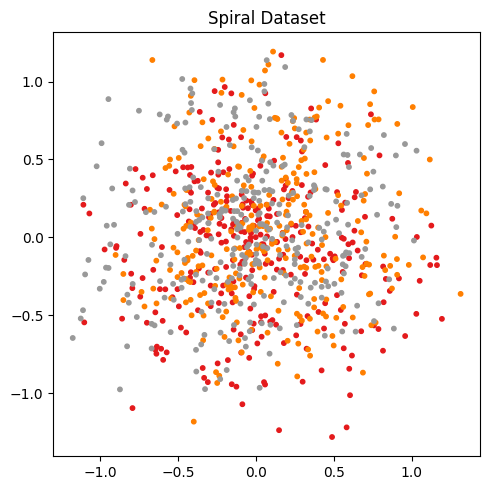

In [ ]:
# ─── Generate spiral data if you don't have the CSV ───────────────────────────
def make_spiral(n_points=300, n_classes=3, noise=0.3):
    X_list, y_list = [], []
    for c in range(n_classes):
        t = np.linspace(0, 4 * np.pi, n_points)
        r = t / (4 * np.pi)
        x1 = r * np.cos(t + 2 * np.pi * c / n_classes) + np.random.randn(n_points) * noise
        x2 = r * np.sin(t + 2 * np.pi * c / n_classes) + np.random.randn(n_points) * noise
        X_list.append(np.column_stack([x1, x2]))
        y_list.append(np.full(n_points, c))
    return np.vstack(X_list), np.hstack(y_list)

np.random.seed(42)
X_spiral, y_spiral = make_spiral(n_points=300, n_classes=3, noise=0.2)

plt.figure(figsize=(5, 5))
plt.scatter(X_spiral[:, 0], X_spiral[:, 1], c=y_spiral, cmap='Set1', s=10)
plt.title('Spiral Dataset')
plt.tight_layout()
plt.show()

In [ ]:
X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_spiral, y_spiral, test_size=0.2, random_state=42)

scaler_sp = StandardScaler()
X_train_sp = scaler_sp.fit_transform(X_train_sp)
X_test_sp  = scaler_sp.transform(X_test_sp)

def train_and_plot_spirals(configs, title, X_tr, y_tr, X_te, y_te):
    n = len(configs)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 9))
    for i, (label, mlp) in enumerate(configs):
        mlp.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, mlp.predict(X_te))
        print(f"{label}  →  Test Acc: {acc:.4f}")
        axes[0, i].plot(mlp.loss_curve_)
        axes[0, i].set_title(f'{label}\nFinal Loss: {mlp.loss_curve_[-1]:.4f}')
        axes[0, i].set_xlabel('Iteration'); axes[0, i].set_ylabel('Loss'); axes[0, i].grid(True)
        plot_decision_regions(X_tr, y_tr, clf=mlp, legend=2, ax=axes[1, i])
        axes[1, i].set_title(f'Decision Regions (Acc={acc:.3f})')
    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

### Task 6.12 — Example 5: tanh, 1 hidden layer, varying width

MLP1 (10)  tanh  →  Test Acc: 0.2722
MLP2 (40)  tanh  →  Test Acc: 0.2889
MLP3 (100) tanh  →  Test Acc: 0.2833


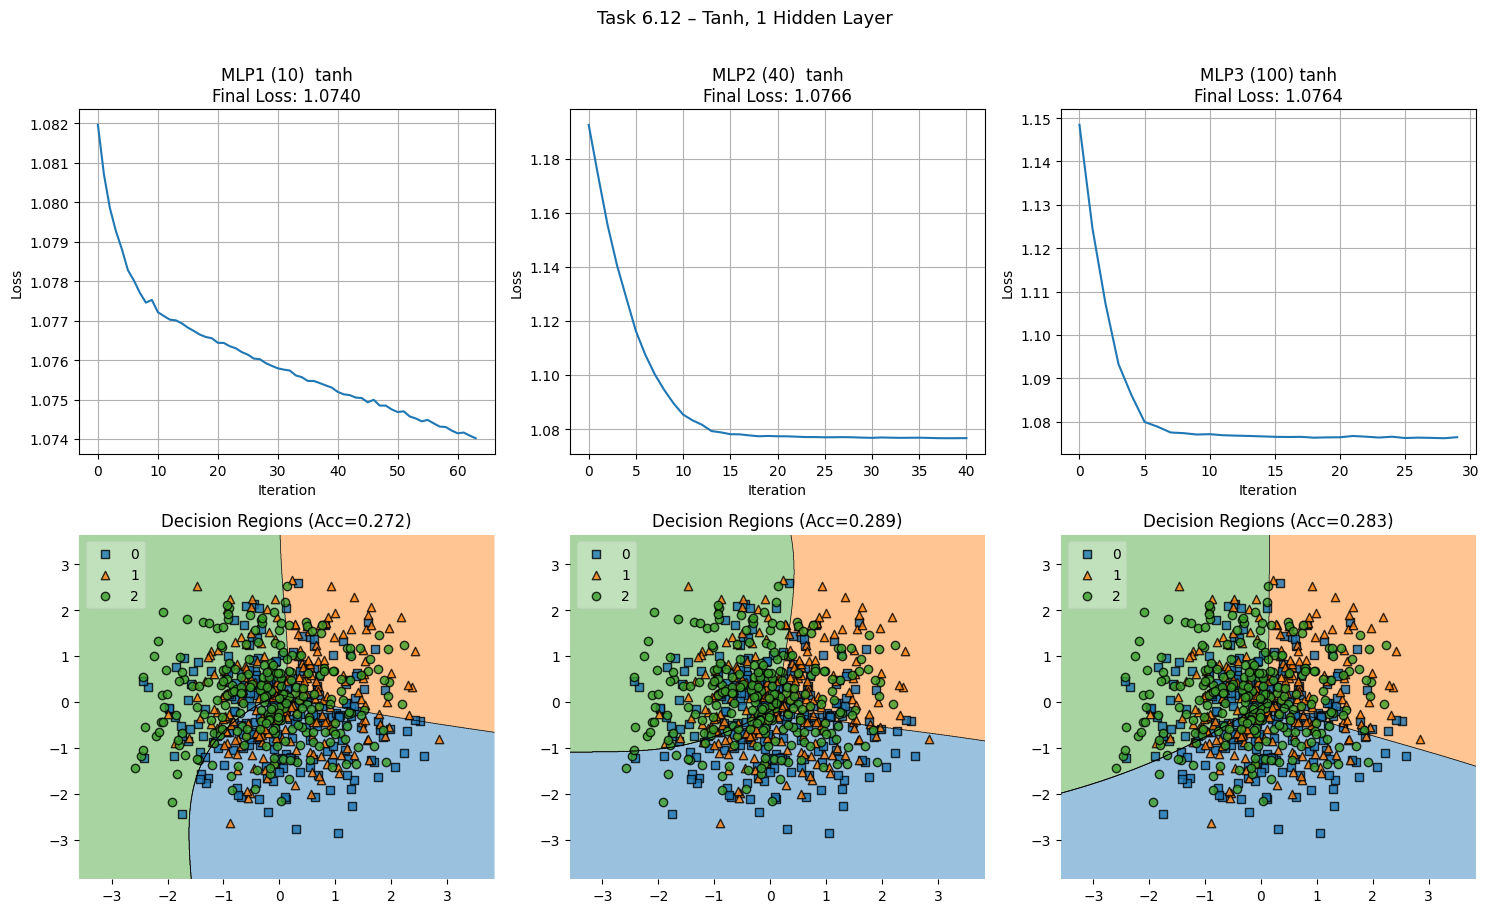

In [ ]:
configs_612 = [
    ('MLP1 (10)  tanh', MLPClassifier(hidden_layer_sizes=(10,),  max_iter=1000, random_state=42, activation='tanh', learning_rate_init=0.001)),
    ('MLP2 (40)  tanh', MLPClassifier(hidden_layer_sizes=(40,),  max_iter=1000, random_state=42, activation='tanh', learning_rate_init=0.001)),
    ('MLP3 (100) tanh', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42, activation='tanh', learning_rate_init=0.001)),
]
train_and_plot_spirals(configs_612, 'Task 6.12 – Tanh, 1 Hidden Layer', X_train_sp, y_train_sp, X_test_sp, y_test_sp)

# --- Answer ---
# MLP3 (100 neurons) typically performs best because the spiral is complex and
# needs more neurons to capture the nonlinear boundaries.

MLP1 (10 neurons, 10000 iter) Acc: 0.2722


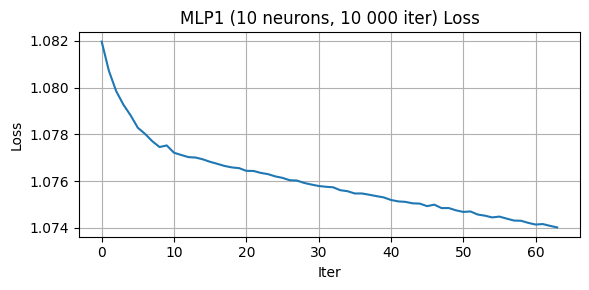

In [ ]:
# Does MLP1 fit with 10,000 iterations?
mlp1_10k = MLPClassifier(hidden_layer_sizes=(10,), max_iter=10000, random_state=42,
                          activation='tanh', learning_rate_init=0.001)
mlp1_10k.fit(X_train_sp, y_train_sp)
acc_10k = accuracy_score(y_test_sp, mlp1_10k.predict(X_test_sp))
print(f"MLP1 (10 neurons, 10000 iter) Acc: {acc_10k:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(mlp1_10k.loss_curve_)
plt.title('MLP1 (10 neurons, 10 000 iter) Loss'); plt.xlabel('Iter'); plt.ylabel('Loss'); plt.grid(True)
plt.tight_layout(); plt.show()
# With only 10 neurons, capacity is still limited → unlikely to perfectly fit the spiral.

### Task 6.13 — ReLU activation

MLP1 (10)  relu  →  Test Acc: 0.2889
MLP2 (40)  relu  →  Test Acc: 0.2889
MLP3 (100) relu  →  Test Acc: 0.3889


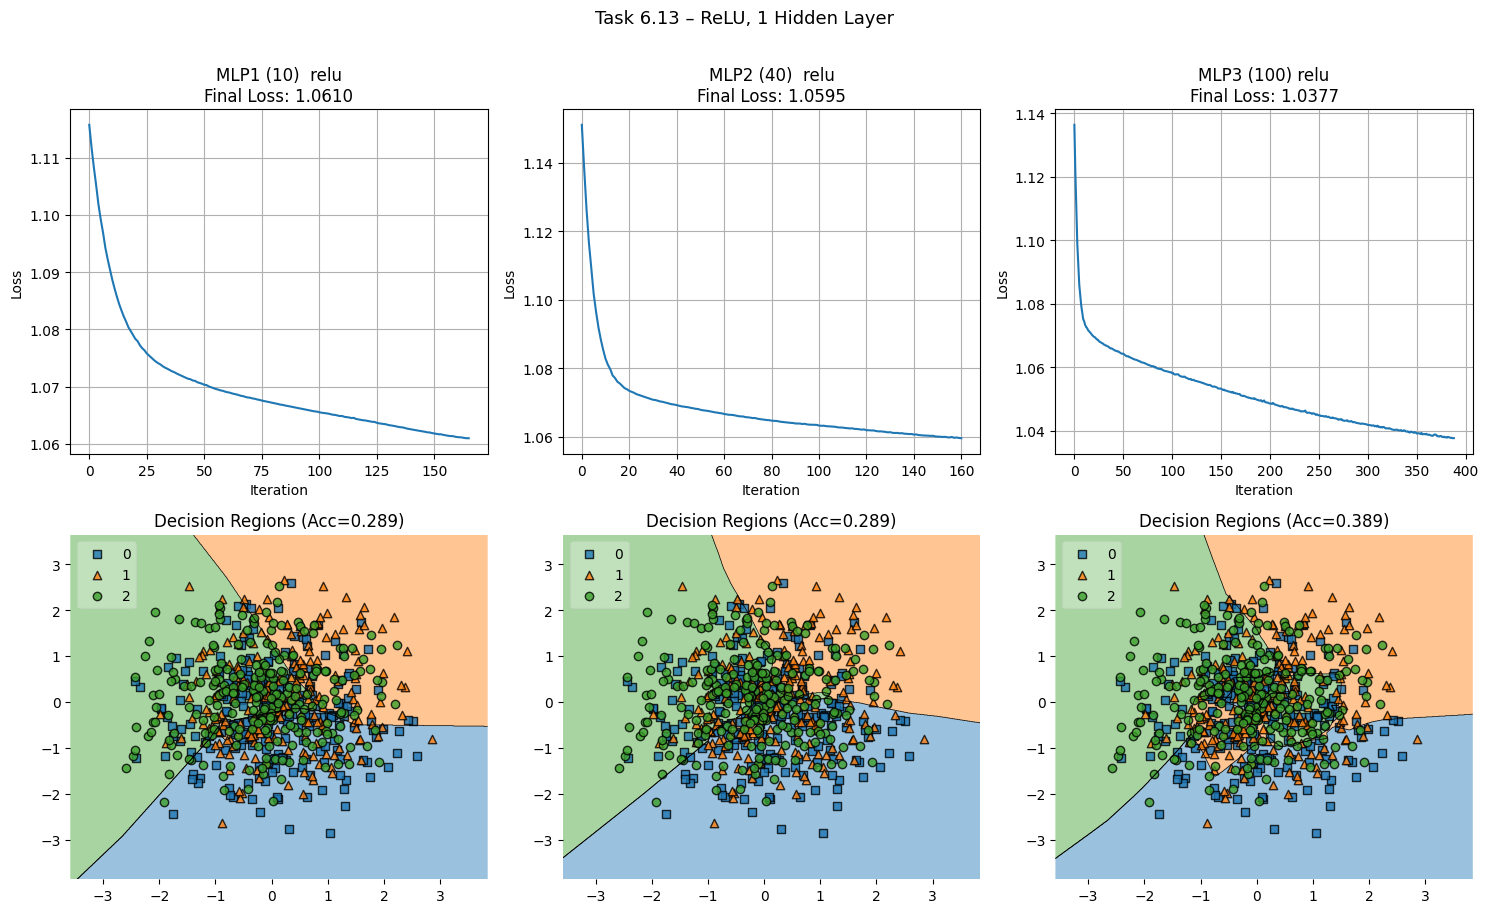

In [ ]:
configs_613 = [
    ('MLP1 (10)  relu', MLPClassifier(hidden_layer_sizes=(10,),  max_iter=1000, random_state=42, activation='relu', learning_rate_init=0.001)),
    ('MLP2 (40)  relu', MLPClassifier(hidden_layer_sizes=(40,),  max_iter=1000, random_state=42, activation='relu', learning_rate_init=0.001)),
    ('MLP3 (100) relu', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42, activation='relu', learning_rate_init=0.001)),
]
train_and_plot_spirals(configs_613, 'Task 6.13 – ReLU, 1 Hidden Layer', X_train_sp, y_train_sp, X_test_sp, y_test_sp)

# --- Observation ---
# ReLU typically converges faster and may achieve better accuracy than tanh on spiral data.
# Decision boundaries are piecewise linear vs. smooth (tanh).

### Task 6.14 — ReLU + Two Hidden Layers

MLP1 (7,3)   relu  →  Test Acc: 0.3222


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP2 (27,13) relu  →  Test Acc: 0.3556
MLP3 (70,30) relu  →  Test Acc: 0.3611


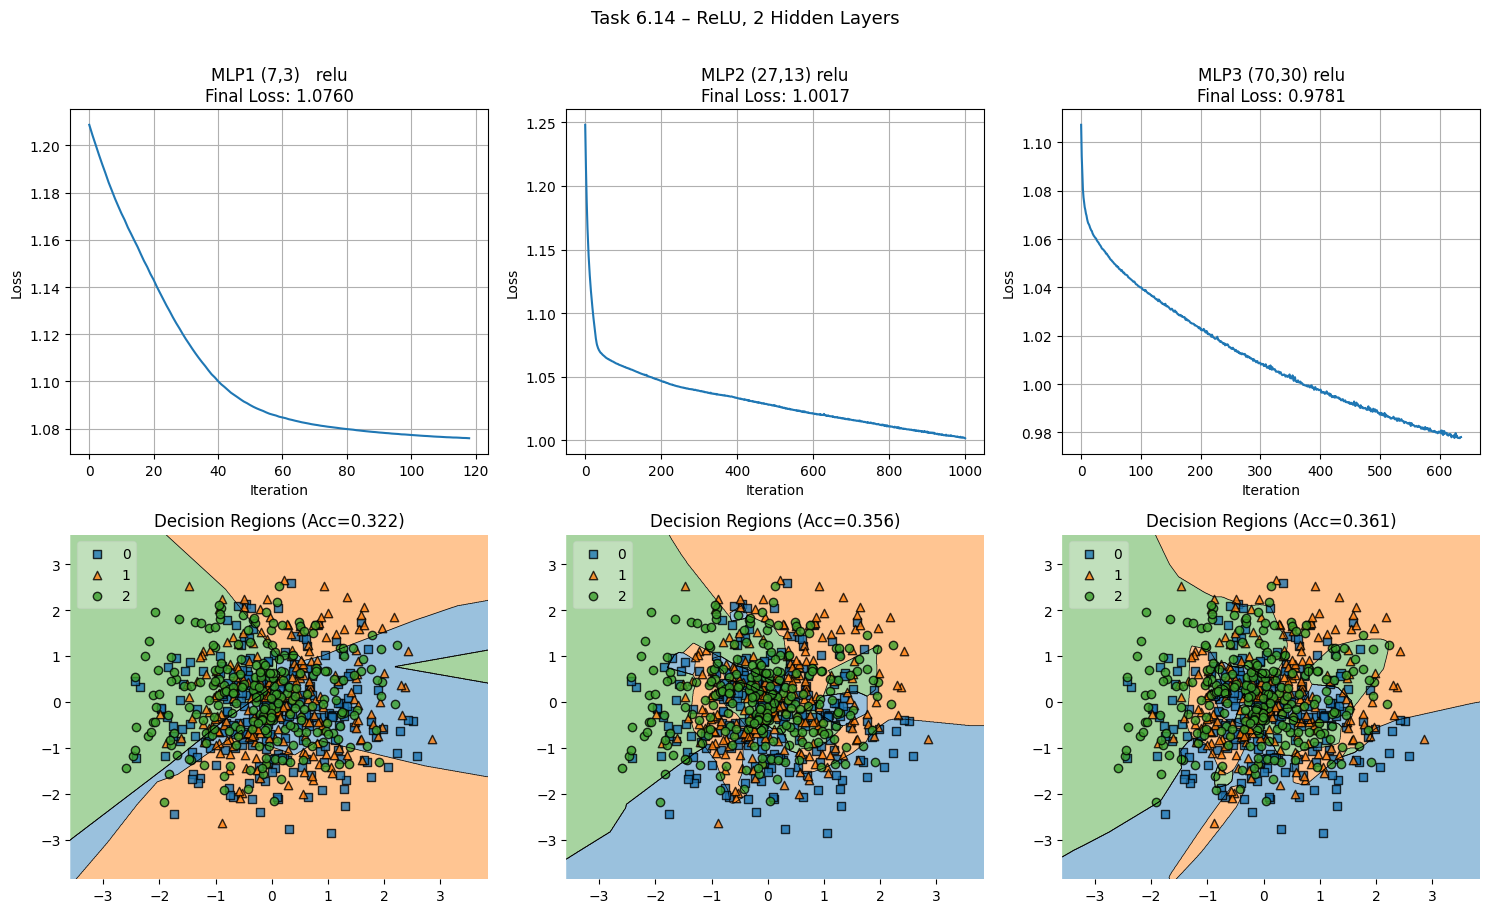

In [ ]:
configs_614 = [
    ('MLP1 (7,3)   relu',  MLPClassifier(hidden_layer_sizes=(7, 3),   max_iter=1000, random_state=42, activation='relu', learning_rate_init=0.001)),
    ('MLP2 (27,13) relu',  MLPClassifier(hidden_layer_sizes=(27, 13), max_iter=1000, random_state=42, activation='relu', learning_rate_init=0.001)),
    ('MLP3 (70,30) relu',  MLPClassifier(hidden_layer_sizes=(70, 30), max_iter=1000, random_state=42, activation='relu', learning_rate_init=0.001)),
]
train_and_plot_spirals(configs_614, 'Task 6.14 – ReLU, 2 Hidden Layers', X_train_sp, y_train_sp, X_test_sp, y_test_sp)

# --- Comparison ---
# Two hidden layers allow hierarchical feature learning.
# MLP3 (70,30) likely performs best, and may outperform the single-layer models
# from Ex5 and Task 6.13 due to deeper representation capacity.

---
## Task 6.15 — GridSearchCV for Automatic Hyperparameter Selection

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001, 'max_iter': 1000}
Best CV Accuracy: 0.4056
Test Accuracy with Best Model: 0.2722


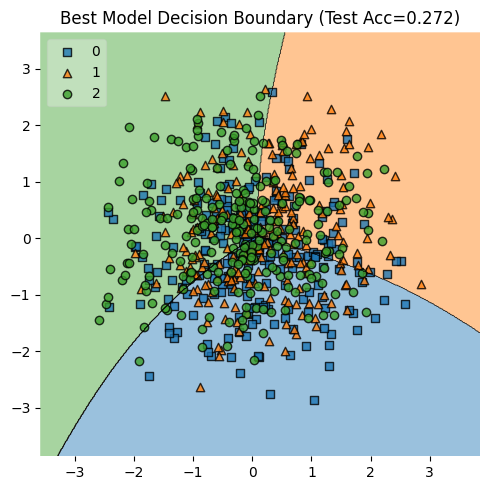

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(10,), (50,), (100,), (35, 15), (70, 30)],
    'activation':         ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter':           [1000],
}

grid_search = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sp, y_train_sp)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

best_mlp = grid_search.best_estimator_
test_acc = accuracy_score(y_test_sp, best_mlp.predict(X_test_sp))
print(f"Test Accuracy with Best Model: {test_acc:.4f}")

plt.figure(figsize=(5, 5))
plot_decision_regions(X_train_sp, y_train_sp, clf=best_mlp, legend=2)
plt.title(f'Best Model Decision Boundary (Test Acc={test_acc:.3f})')
plt.tight_layout()
plt.show()

---
## Example 6 & Task 6.16 — Regularization (alpha) to Handle Overfitting

Three MLP classifiers on noisy spiral data with alpha = 0, 0.001, 0.3.

alpha=0  →  Train Loss: 0.9448  |  Test Acc: 0.3000
alpha=0.001  →  Train Loss: 0.9927  |  Test Acc: 0.3056
alpha=0.3  →  Train Loss: 1.0672  |  Test Acc: 0.3111


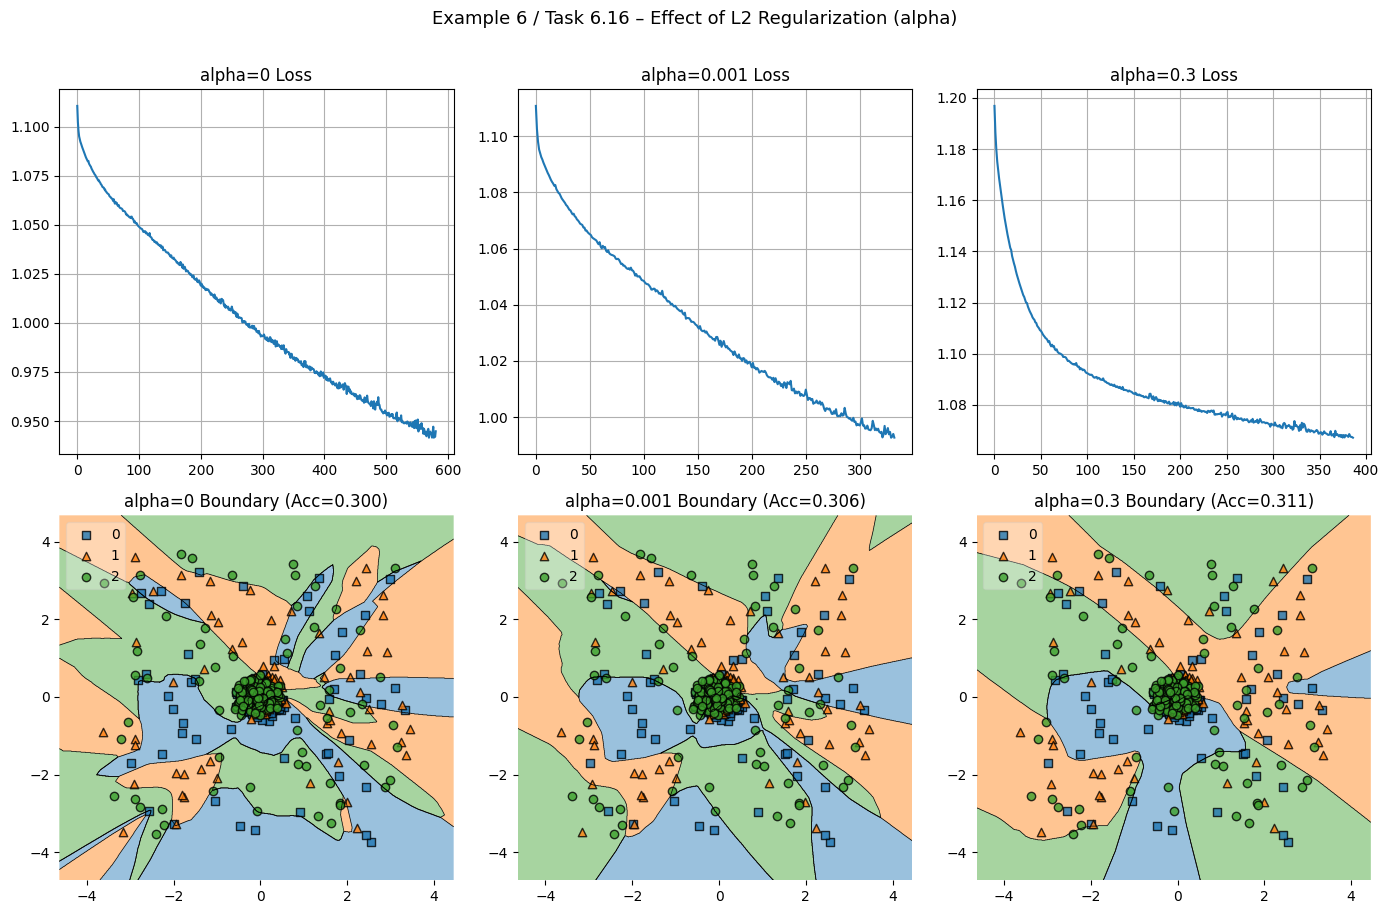

In [ ]:
# Add outliers to the spiral data
np.random.seed(42)
X_noisy = X_spiral.copy()
outlier_fraction = 0.2
outliers_mask = np.random.rand(X_noisy.shape[0]) < outlier_fraction
X_noisy[outliers_mask] += np.random.uniform(-7, 7, (np.sum(outliers_mask), 2))

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y_spiral, test_size=0.2, random_state=42)

scaler_n = StandardScaler()
X_train_n = scaler_n.fit_transform(X_train_n)
X_test_n  = scaler_n.transform(X_test_n)

common_kwargs = dict(
    hidden_layer_sizes=(100, 50, 20), max_iter=1000, random_state=42,
    solver='adam', learning_rate_init=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-8
)

mlp6_1 = MLPClassifier(**common_kwargs)                    # no regularization
mlp6_2 = MLPClassifier(**common_kwargs, alpha=0.001)       # light L2
mlp6_3 = MLPClassifier(**common_kwargs, alpha=0.3)         # heavy L2

for mlp, lbl in [(mlp6_1, 'alpha=0'), (mlp6_2, 'alpha=0.001'), (mlp6_3, 'alpha=0.3')]:
    mlp.fit(X_train_n, y_train_n)
    acc = accuracy_score(y_test_n, mlp.predict(X_test_n))
    print(f"{lbl}  →  Train Loss: {mlp.loss_curve_[-1]:.4f}  |  Test Acc: {acc:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, (mlp, alpha_val) in enumerate([(mlp6_1, 0), (mlp6_2, 0.001), (mlp6_3, 0.3)]):
    acc = accuracy_score(y_test_n, mlp.predict(X_test_n))
    axes[0, i].plot(mlp.loss_curve_)
    axes[0, i].set_title(f'alpha={alpha_val} Loss'); axes[0, i].grid(True)
    plot_decision_regions(X_train_n, y_train_n, clf=mlp, legend=2, ax=axes[1, i])
    axes[1, i].set_title(f'alpha={alpha_val} Boundary (Acc={acc:.3f})')

plt.suptitle('Example 6 / Task 6.16 – Effect of L2 Regularization (alpha)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Task 6.16 answer ---
# alpha=0   → risk of overfitting noisy data; very complex boundary
# alpha=0.001 → slight regularization; smoothed boundary; often best test accuracy
# alpha=0.3 → heavy regularization; smoother/simpler boundary; may underfit
# The intermediate alpha (0.001) typically gives the best generalization.